In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage 
from skimage import io, color, filters, util, data, transform, feature

In [6]:
def harris_corner_detector(image, alpha=0.05, threshold=1e-3, window_size=3, sigma=1.0):
    # 1. Compute image derivatives
    Ix = filters.sobel_h(image) # compute horizontal derivative (x-direction)
    Iy = filters.sobel_v(image) # compute vertical derivative (y-direction)

    # 2. Compute products of derivatives
    Ixx = np.multiply(Ix, Ix) # Compute using hadamard product
    Iyy = np.multiply(Iy, Iy)# Compute using hadamard product
    Ixy = np.multiply(Ix, Iy)# Compute using hadamard product

    # 3. Gaussian filter to smooth the squared derivatives
    Sxx = filters.gaussian(Ixx, sigma=sigma) # Gaussian filter of Ixx
    Syy = filters.gaussian(Iyy, sigma=sigma) # Gaussian filter of Iyy
    Sxy = filters.gaussian(Ixy, sigma=sigma) # Gaussian filter of Ixy

    # 4. Compute cornerness 
    detM = np.multiply(Sxx, Syy) - (Sxy ** 2) # Must be a function of only Sxx, Syy, or Sxy
    traceM = Sxx + Syy # Must be a function of only Sxx, Syy, or Sxy
    C = detM - alpha * (traceM ** 2) # C Must be a function of only detM, traceM, and alpha

    # 5. Threshold C to remove weak corners
    C_thresh = (C > threshold * C.max()) * C

    # 6. Non-maximum suppression
    win_half_size = int(window_size // 2)
    corners = []
    for y in range(win_half_size, C.shape[0]-win_half_size):
        for x in range(win_half_size, C.shape[1]-win_half_size):
            if C_thresh[y, x] == np.max(C_thresh[y-win_half_size : y+win_half_size+1,  x-win_half_size : x+win_half_size+1]):
                if C_thresh[y, x] > 0:
                    corners.append((y, x))

    return corners, C

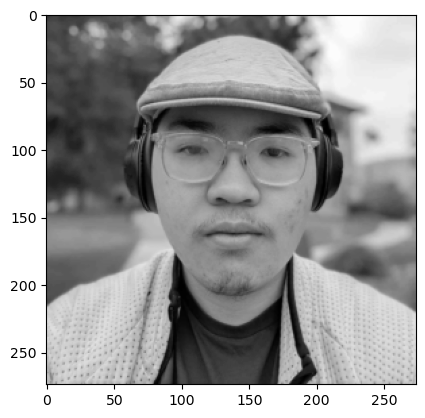

In [3]:
# load input image
img = util.img_as_float32( color.rgb2gray( io.imread('./assignment1_photo.jpg') ) )
img = transform.rescale(img, 1/5)
plt.imshow(img, cmap='gray')
plt.show()

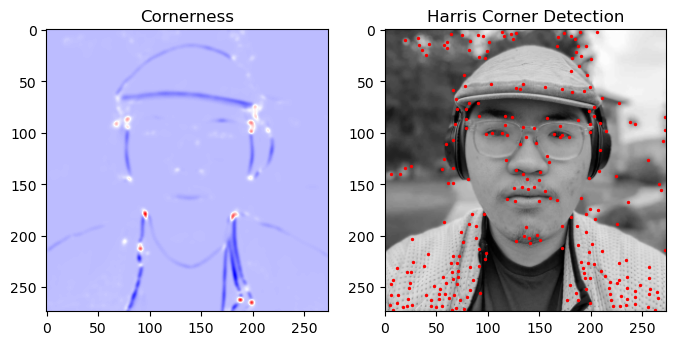

In [8]:
# Harris corner detection
threshold=1e-3
alpha=0.05
window_size=3
sigma=2.0
corners, C = harris_corner_detector(img, alpha, threshold, window_size, sigma)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
ax[0].imshow(C, cmap='bwr')
ax[0].set_title("Cornerness")
ax[1].imshow(img, cmap='gray')
y, x = zip(*corners)
ax[1].scatter(x, y, c='r', s=2)
ax[1].set_title("Harris Corner Detection")
plt.show()